## Import Libraries

In [1]:
import os
import shutil
import random
import cv2
from PIL import Image
import matplotlib.pyplot as plt

## Train / Test / Validation
This code block creates a 70-20-10 train/validation/test split

In [ ]:
# Set the path to your source folder containing the images
source_folder = "/Users/ehessick/Documents/OSU/2024-2025/Capstone/EyesPy/data/10-30-2024/CAM0_data/"

# Set the path where you want to create the new folders
destination_path = "/Users/ehessick/Documents/OSU/2024-2025/Capstone/EyesPy/data/10-30-2024/model_data/"

# Create the Train, Validation, and Test folders
folders = ["Train", "Validation", "Test"]
for folder in folders:
    os.makedirs(os.path.join(destination_path, folder), exist_ok=True)

# Get a list of all image files in the source folder
image_files = [f for f in os.listdir(source_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

# Shuffle the list of image files randomly
random.shuffle(image_files)

# Calculate the number of images for each folder
total_images = len(image_files)
train_split = int(total_images * 0.7)  # 70% for training
val_split = int(total_images * 0.2)   # 20% for validation
# The remaining 15% will go to the test folder

# Distribute the images into the folders
for i, image in enumerate(image_files):
    source = os.path.join(source_folder, image)
    if i < train_split:
        destination = os.path.join(destination_path, "Train", image)
    elif i < train_split + val_split:
        destination = os.path.join(destination_path, "Validation", image)
    else:
        destination = os.path.join(destination_path, "Test", image)
    
    shutil.copy2(source, destination)

print(f"Total images: {total_images}")
print(f"Images in Train: {train_split}")
print(f"Images in Validation: {val_split}")
print(f"Images in Test: {total_images - train_split - val_split}")

## Video to frames

In [28]:


# Function to extract frames from a video
def video_to_frames(video_path):
    # Create a VideoCapture object to read the video
    video = cv2.VideoCapture(video_path)
    
    # Check if the video was opened successfully
    if not video.isOpened():
        print(f"Error: Could not open video {video_path}")
        return
    
    # Get the video's frame count
    frame_count = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Get the directory and filename of the input video
    video_dir, video_filename = os.path.split(video_path)
    
    # Create a directory to save frames (same directory as the video)
    frame_dir = os.path.join(video_dir, os.path.splitext(video_filename)[0] + '_frames')
    os.makedirs(frame_dir, exist_ok=True)

    # Loop through each frame in the video
    for i in range(frame_count):
        ret, frame = video.read()
        if not ret:
            break  # Stop if no more frames are available
        
        # Save each frame as an image file (JPEG format)
        frame_filename = os.path.join(frame_dir, f'frame_{i:04d}.jpg')
        cv2.imwrite(frame_filename, frame)

    # Release the VideoCapture object
    video.release()
    
    print(f'Successfully saved {frame_count} frames to {frame_dir}.')

# Example usage of the function
# Replace 'path_to_your_video.mp4' with the actual path to your video file
# Ethan's path = '/Users/ethanhessick/Library/CloudStorage/OneDrive-SharedLibraries-TheOhioStateUniversity/MPD Eye Machine Learning Capstone - Eye Image Data/Data Labeling/Modeling data/Ethan_Blinking_Data/Video/Ethan Blinking Slow Mo.mov'
video_to_frames('/Users/ethanhessick/Library/CloudStorage/OneDrive-SharedLibraries-TheOhioStateUniversity/MPD Eye Machine Learning Capstone - Eye Image Data/Data Labeling/Modeling data/Ethan_Blinking_Data/Ethan_240fps_1080p.mov')


Successfully saved 944 frames to /Users/ethanhessick/Library/CloudStorage/OneDrive-SharedLibraries-TheOhioStateUniversity/MPD Eye Machine Learning Capstone - Eye Image Data/Data Labeling/Modeling data/Ethan_Blinking_Data/Ethan_240fps_1080p_frames.


## Crop images to only show the eyes

In [ ]:
# # test bounding box of eye
# from PIL import Image
# import matplotlib.pyplot as plt

# def crop_center(image_path, square_offset=256):
#     """
#     Crops the center 256x256 pixels from an image and displays it.
    
#     :param image_path: Path to the input image file.
#     """
#     try:
#         # Open the image
#         img = Image.open(image_path)
        
#         # Get dimensions
#         width, height = img.size
        
#         # Calculate the coordinates for the center crop
#         left = (width - square_offset) // 2
#         top = (height - square_offset) // 2
#         right = left + square_offset
#         bottom = top + square_offset
        
#         # Crop the image
#         cropped_img = img.crop((left, top, right, bottom))
        
#         # Display the cropped image
#         # cropped_img.show()
#         plt.imshow(cropped_img)
    
#     except Exception as e:
#         print(f"An error occurred: {e}")

# # Example usage
# # Replace 'input.jpg' with the path to your image
# image_path = '/Users/mihirjoshi/Documents/OSU/2024-2025/Capstone/EyesPy/data/mihir_blinking/blinking_240fps_frames/frame_0000.jpg'  
# crop_center(image_path, square_offset=256)

## Specify bounding box for eye

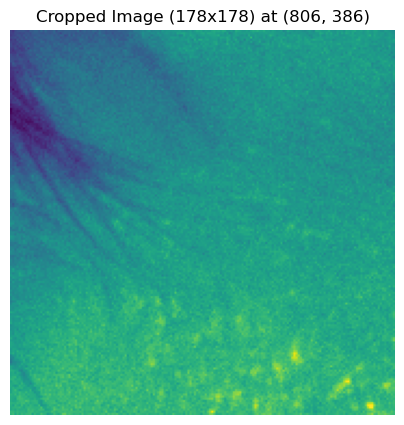

In [4]:

def crop_custom(image_path, x, y, w, h):
    """
    Crops an image to the specified rectangle and displays it using matplotlib.
    
    :param image_path: Path to the input image file.
    :param x: The x-coordinate of the top-left corner of the crop area.
    :param y: The y-coordinate of the top-left corner of the crop area.
    :param w: The width of the crop area.
    :param h: The height of the crop area.
    """
    try:
        # Open the image
        img = Image.open(image_path)
        
        # Calculate the crop box
        left = x
        top = y
        right = x + w
        bottom = y + h
        
        # Crop the image
        cropped_img = img.crop((left, top, right, bottom))
        
        # Display the cropped image using matplotlib
        plt.figure(figsize=(5, 5))
        plt.imshow(cropped_img)
        plt.axis('off')  # Hide axes
        plt.title(f"Cropped Image ({w}x{h}) at ({x}, {y})")
        plt.show()
    
    except Exception as e:
        print(f"An error occurred: {e}")

# Example usage
# Replace 'input.jpg' with the path to your image
image_path = '/Users/ethanhessick/Library/CloudStorage/OneDrive-SharedLibraries-TheOhioStateUniversity/MPD Eye Machine Learning Capstone - Eye Image Data/Data Labeling/CAM0_Usable_Data/Ethan/1599577820871.bmp'  
crop_custom(image_path, x=806, y=386, w=178, h=178)

## Identify left and right eyes (from Claude)

In [ ]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def display_eye_detections(image_path, output_dir, showPlot=True):
    """
    Detect and save eye images from a face image
    
    Args:
        image_path (str): Path to input image
        output_dir (str): Directory to save the eye images
        showPlot (bool): Whether to display the detection results
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Could not load image")

    # Get base filename without extension
    base_filename = os.path.splitext(os.path.basename(image_path))[0]
    
    # Convert to RGB for matplotlib display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # Convert to grayscale for detection
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Load the pre-trained classifiers
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    
    # Detect faces with adjusted parameters
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    if len(faces) == 0:
        raise ValueError("No faces detected in the image")
        
    # Create figure with subplots
    if showPlot:
        plt.figure(figsize=(15, 5))
        
    # We'll work with the first face found
    x, y, w, h = faces[0]
    # Draw rectangle around the face
    image_with_rect = image_rgb.copy()
    cv2.rectangle(image_with_rect, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
    # Get the face region
    face_roi = gray[y:y+h, x:x+w]
    face_roi_color = image_rgb[y:y+h, x:x+w]
    
    # Detect eyes in the face region with adjusted parameters
    eyes = eye_cascade.detectMultiScale(
        face_roi,
        scaleFactor=1.1,
        minNeighbors=6,
        minSize=(int(w/10), int(h/10)),
        maxSize=(int(w/3), int(h/3))
    )
    
    # Filter eyes based on vertical position
    valid_eyes = []
    face_upper_half = h/2
    for eye in eyes:
        ex, ey, ew, eh = eye
        if ey + eh/2 < face_upper_half:
            valid_eyes.append(eye)
            
    # Sort eyes by x-coordinate to get left and right eye
    valid_eyes = sorted(valid_eyes, key=lambda x: x[0])
    
    # If we still don't have exactly 2 eyes, try to adjust detection
    if len(valid_eyes) != 2:
        eyes = eye_cascade.detectMultiScale(
            face_roi,
            scaleFactor=1.05,
            minNeighbors=8,
            minSize=(int(w/12), int(h/12)),
            maxSize=(int(w/3), int(h/3))
        )
        valid_eyes = [eye for eye in eyes if eye[1] + eye[3]/2 < face_upper_half]
        valid_eyes = sorted(valid_eyes, key=lambda x: x[0])
        
    if len(valid_eyes) < 2:
        raise ValueError("Could not detect both eyes properly in the image")
        
    # Take only the first two detected eyes
    valid_eyes = valid_eyes[:2]
    eye_images = []
    
    # Draw rectangles around eyes and crop them
    for i, (ex, ey, ew, eh) in enumerate(valid_eyes):
        # Draw rectangle for each eye
        cv2.rectangle(image_with_rect,
                     (x + ex, y + ey),
                     (x + ex + ew, y + ey + eh),
                     (255, 0, 0), 2)
        
        # Crop eye region
        eye_roi = image_rgb[y+ey:y+ey+eh, x+ex:x+ex+ew]
        eye_images.append(eye_roi)
        
        # Save eye image
        eye_type = "left" if i == 0 else "right"
        output_path = os.path.join(output_dir, f"{base_filename}_{eye_type}_eye.jpg")
        
        # Convert from RGB to BGR for cv2.imwrite
        eye_bgr = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2BGR)
        cv2.imwrite(output_path, eye_bgr)
        
    if showPlot:
        # Show image with all detections
        plt.subplot(1, 3, 1)
        plt.imshow(image_with_rect)
        plt.title('Detected Face and Eyes')
        plt.axis('off')
        
        # Show left eye
        plt.subplot(1, 3, 2)
        plt.imshow(eye_images[0])
        plt.title('Left Eye')
        plt.axis('off')
        
        # Show right eye
        plt.subplot(1, 3, 3)
        plt.imshow(eye_images[1])
        plt.title('Right Eye')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
    return eye_images

## Identify left and right eyes (from Claude) - EYES ONLY

In [54]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def display_only_eye_detections(image_path, output_dir, showPlot=True):
    """
    Detect and save eye images from a face image
    
    Args:
        image_path (str): Path to input image
        output_dir (str): Directory to save the eye images
        showPlot (bool): Whether to display the detection results
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Could not load image")

    # Get base filename without extension
    base_filename = os.path.splitext(os.path.basename(image_path))[0]
    
    # Convert to RGB for matplotlib display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # Convert to grayscale for detection
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Load the pre-trained classifiers
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    
    # Set x, y, w, h
    x = 0
    y = 0

    img_size = np.shape(gray)
    w = img_size[1]
    h = img_size[0]
    
    # Make a face copy to allow us to show a picture with eyes circled
    image_with_rect = image_rgb.copy()

    # Detect eyes in the face region with adjusted parameters
    eyes = eye_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=6,
        minSize=(int(w/12), int(h/12)),
        maxSize=(int(w/3), int(h/3))
    )
    
    # Filter eyes based on vertical position
    valid_eyes = []
    face_upper_half = h/2
    for eye in eyes:
        ex, ey, ew, eh = eye
        if ey + eh/2 < face_upper_half:
            valid_eyes.append(eye)
            
    # Sort eyes by x-coordinate to get left and right eye
    valid_eyes = sorted(valid_eyes, key=lambda x: x[0])
    
    # If we still don't have exactly 2 eyes, try to adjust detection
    if len(valid_eyes) != 2:
        eyes = eye_cascade.detectMultiScale(
            gray,
            scaleFactor=1.05,
            minNeighbors=8,
            minSize=(int(w/12), int(h/12)),
            maxSize=(int(w/3), int(h/3))
        )
        valid_eyes = [eye for eye in eyes if eye[1] + eye[3]/2 < face_upper_half]
        valid_eyes = sorted(valid_eyes, key=lambda x: x[0])
        
    if len(valid_eyes) < 2:
        raise ValueError(f"Could not detect both eyes properly in image {base_filename}")
        
    # Take only the first two detected eyes
    valid_eyes = valid_eyes[:2]
    eye_images = []
    
    # Draw rectangles around eyes and crop them
    for i, (ex, ey, ew, eh) in enumerate(valid_eyes):
        # Draw rectangle for each eye
        cv2.rectangle(image_with_rect,
                     (x + ex, y + ey),
                     (x + ex + ew, y + ey + eh),
                     (255, 0, 0), 2)
        
        # Crop eye region
        eye_roi = image_rgb[y+ey:y+ey+eh, x+ex:x+ex+ew]
        eye_images.append(eye_roi)
        
        # Save eye image
        eye_type = "left" if i == 0 else "right"
        output_path = os.path.join(output_dir, f"{base_filename}_{eye_type}_eye.jpg")
        
        # Convert from RGB to BGR for cv2.imwrite
        eye_bgr = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2BGR)
        cv2.imwrite(output_path, eye_bgr)
        
    if showPlot:
        # Show image with all detections
        plt.subplot(1, 3, 1)
        plt.imshow(image_with_rect)
        plt.title('Detected Eyes on Image')
        plt.axis('off')
        
        # Show left eye
        plt.subplot(1, 3, 2)
        plt.imshow(eye_images[0])
        plt.title('Left Eye')
        plt.axis('off')
        
        # Show right eye
        plt.subplot(1, 3, 3)
        plt.imshow(eye_images[1])
        plt.title('Right Eye')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
    return eye_images

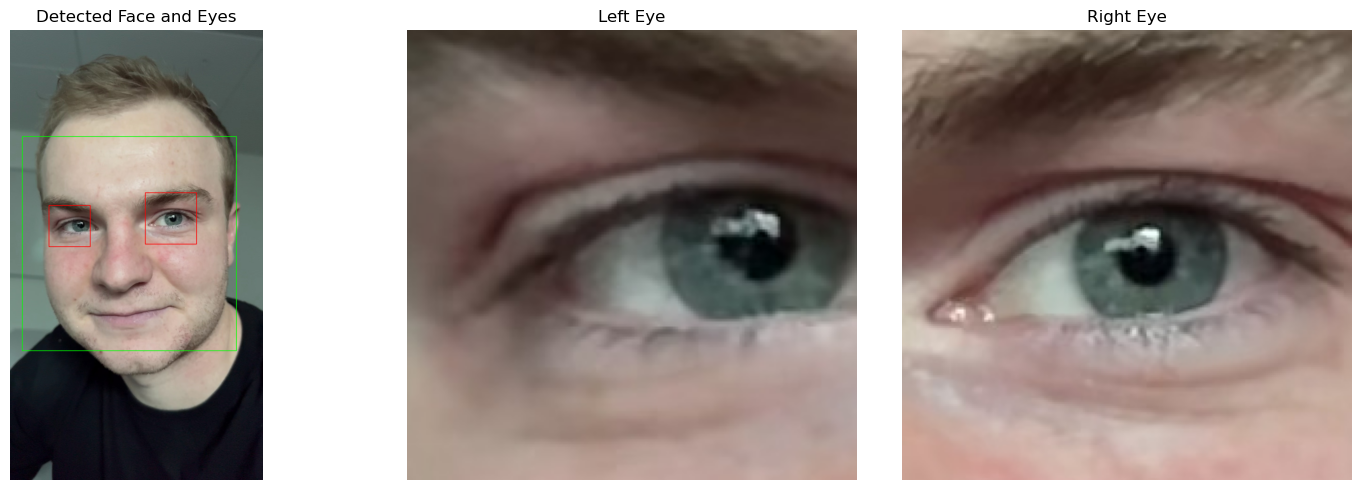

[array([[[ 61,  52,  43],
         [ 62,  53,  44],
         [ 63,  54,  45],
         ...,
         [151, 133, 119],
         [153, 134, 120],
         [154, 135, 121]],
 
        [[ 62,  53,  44],
         [ 63,  54,  45],
         [ 63,  54,  45],
         ...,
         [149, 131, 117],
         [149, 130, 116],
         [149, 130, 116]],
 
        [[ 62,  55,  45],
         [ 62,  55,  45],
         [ 63,  54,  45],
         ...,
         [145, 127, 113],
         [145, 126, 112],
         [143, 124, 110]],
 
        ...,
 
        [[176, 158, 144],
         [175, 157, 143],
         [176, 158, 144],
         ...,
         [192, 158, 146],
         [194, 158, 146],
         [192, 158, 146]],
 
        [[175, 157, 143],
         [175, 157, 143],
         [176, 158, 144],
         ...,
         [192, 156, 144],
         [193, 155, 144],
         [193, 157, 145]],
 
        [[175, 157, 143],
         [174, 156, 142],
         [175, 157, 143],
         ...,
         [192, 154, 143],
  

In [53]:
image_path = '/Users/ethanhessick/Library/CloudStorage/OneDrive-SharedLibraries-TheOhioStateUniversity/MPD Eye Machine Learning Capstone - Eye Image Data/Data Labeling/Modeling data/Ethan_Blinking_Data/Ethan_240fps_1080p_frames/frame_0000.jpg'
output_path = './'

display_eye_detections(image_path, output_path, showPlot=True)

### Iterate through directory to save cropped left and right images

In [55]:
original_directory = '/Users/ethanhessick/Library/CloudStorage/OneDrive-SharedLibraries-TheOhioStateUniversity/MPD Eye Machine Learning Capstone - Eye Image Data/Data Labeling/Modeling data/Ethan_Blinking_Data/Ethan_240fps_1080p_frames/'
output_directory = original_directory + 'isolated_eyes/'


# Supported image file extensions
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff")

# Iterate through all files in the folder
for filename in os.listdir(original_directory):
    file_path = os.path.join(original_directory, filename)
    
    display_only_eye_detections(file_path, output_directory, showPlot=False)  



ValueError: Could not detect both eyes properly in image frame_0767